In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [2]:
df = pd.read_csv(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\data\processed\model_ready_dataset.csv")

In [3]:
X = df.drop("Machine failure",axis=1)
y = df["Machine failure"]

leak_columns = [
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = X.drop(columns=[col for col in leak_columns if col in X.columns],errors="ignore")

In [4]:
X.columns = (
    X.columns
    .str.replace("[","",regex=False)
    .str.replace("]","",regex=False)
    .str.replace("{","",regex=False)
    .str.replace("}","",regex=False)
    .str.replace(":","",regex=False)
    .str.replace(",","",regex=False)
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [6]:
model = joblib.load(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\models\final_lightgbm_model.pkl")

In [7]:
def add_noise(data, level):
    noisy = data.copy()

    noise = np.random.normal(loc=0,scale=level,size=noisy.shape)

    return noisy + noise

In [9]:
best_threshold = 0.80000

results = []

noise_levels = [0.00,0.01,0.03,0.05,0.10]

for level in noise_levels:
    if level == 0:
        X_eval = X_test.copy()
    else:
        X_eval = add_noise(X_test,level)
    probablities = model.predict_proba(X_eval)[:,1]
    predictions = (probablities>=best_threshold).astype(int)

    results.append({
        "Noise Level":level,
        "Accuracy":accuracy_score(y_test,predictions),
        "Precision":precision_score(y_test,predictions,zero_division=0),
        "Recall":recall_score(y_test,predictions,zero_division=0),
        "F1 Score":f1_score(y_test,predictions,zero_division=0)
    })

In [10]:
deployment_df = pd.DataFrame(results)

deployment_df

,Noise Level,Accuracy,Precision,Recall,F1 Score
0,0.00,0.989985,0.852941,0.852941,0.852941
1,0.01,0.980471,0.659341,0.882353,0.754717
2,0.03,0.982974,0.693182,0.897059,0.782051
3,0.05,0.980971,0.674419,0.852941,0.753247
4,0.10,0.983976,0.709302,0.897059,0.792208


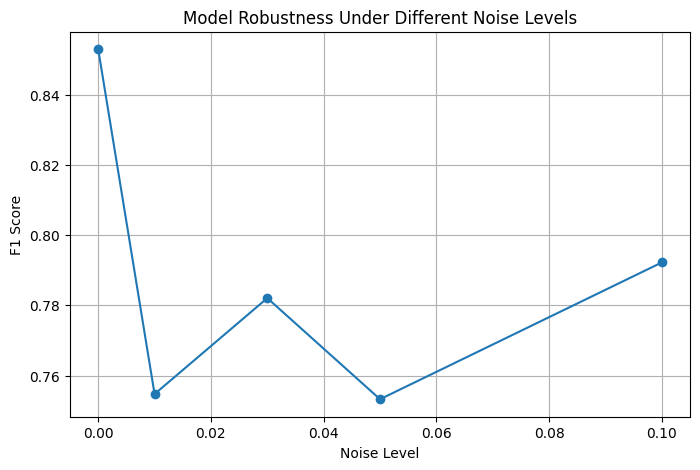

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    deployment_df["Noise Level"],
    deployment_df["F1 Score"],
    marker="o"
)

plt.xlabel("Noise Level")
plt.ylabel("F1 Score")
plt.title("Model Robustness Under Different Noise Levels")

plt.grid(True)

plt.show()

In [12]:
deployment_df.to_csv(r"E:\AARAV\Infotact-DS-ML\Project-1-Predictive-Maintenance\data\processed\deployment_validation_results.csv",index=False)